In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Bidirectional,
    LSTM,
    Dense,
    GlobalMaxPooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)
print("Seed set to:", SEED)

Libraries imported successfully.
TensorFlow version: 2.19.0
Seed set to: 42


In [3]:
from datasets import load_dataset

dataset = load_dataset("dnagpt/dna_splice_site_prediction")
df = dataset["train"].to_pandas()

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/314 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/8.80M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45619 [00:00<?, ? examples/s]

Dataset loaded successfully.
Shape: (45619, 2)
Columns: ['sequence', 'label']


,sequence,label
0,GTCCAGCCAACATGGAGAAGTACATTTCTAGGGACTAAACCTGGCT...,1
1,GAGATTACAGGCATGAGCCACCATACTCAGCCATAGTTTCCTAATC...,0
2,CAGGAGATATCCAGTTAAATTAATTAGCTTTTCTTTCCACTCCAAC...,2
3,GCCCAACTGTAAACATCAGTGCACATGTATTGATGGCGCCGTGGGC...,2
4,GCATACTTGTTCTTCAGTATCGTGTGTCTGATGCTGCTGAGCGTGG...,2


In [4]:
print("Columns:", df.columns.tolist())

SEQ_COL = df.columns[0]
LABEL_COL = df.columns[1]

print("Using sequence column:", SEQ_COL)
print("Using label column:", LABEL_COL)

Columns: ['sequence', 'label']
Using sequence column: sequence
Using label column: label


Class distribution:
label
0    10000
1     9999
2    25620
Name: count, dtype: int64

Sequence length statistics:
count    45619.0
mean       400.0
std          0.0
min        400.0
25%        400.0
50%        400.0
75%        400.0
max        400.0
Name: sequence, dtype: float64


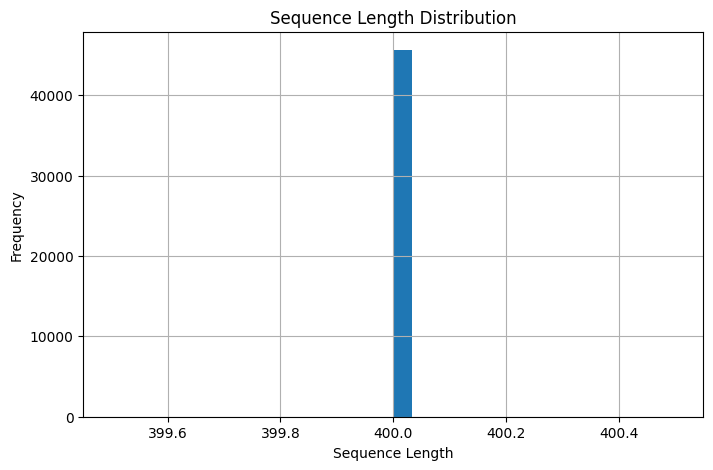

In [5]:
print("Class distribution:")
print(df[LABEL_COL].value_counts().sort_index())
print()

sequence_lengths = df[SEQ_COL].astype(str).apply(len)
print("Sequence length statistics:")
print(sequence_lengths.describe())

plt.figure(figsize=(8, 5))
plt.hist(sequence_lengths, bins=30)
plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [6]:
X_seq = df[SEQ_COL].astype(str).str.upper().values
y = df[LABEL_COL].values

print("Number of sequences:", len(X_seq))
print("Number of labels:", len(y))
print("Original classes:", sorted(pd.Series(y).unique()))

Number of sequences: 45619
Number of labels: 45619
Original classes: [np.int64(0), np.int64(1), np.int64(2)]


In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:", sorted(np.unique(y_encoded)))

y_categorical = to_categorical(y_encoded)

print("Categorical label shape:", y_categorical.shape)

Encoded classes: [np.int64(0), np.int64(1), np.int64(2)]
Categorical label shape: (45619, 3)


In [8]:
MAX_LEN = max(len(seq) for seq in X_seq)

print("Using MAX_LEN =", MAX_LEN)

mapping = {
    "A": [1, 0, 0, 0],
    "C": [0, 1, 0, 0],
    "G": [0, 0, 1, 0],
    "T": [0, 0, 0, 1],
    "N": [0, 0, 0, 0]
}

def encode_sequence(seq, max_len):
    seq = seq.upper()

    if len(seq) < max_len:
        seq = seq + "N" * (max_len - len(seq))
    else:
        seq = seq[:max_len]

    return np.array([mapping.get(base, [0, 0, 0, 0]) for base in seq], dtype=np.float32)

X = np.array([encode_sequence(seq, MAX_LEN) for seq in X_seq])

print("X shape:", X.shape)
print("y shape:", y_categorical.shape)

Using MAX_LEN = 400
X shape: (45619, 400, 4)
y shape: (45619, 3)


In [9]:
X_train, X_temp, y_train, y_temp, y_train_raw, y_temp_raw = train_test_split(
    X,
    y_categorical,
    y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test, y_val_raw, y_test_raw = train_test_split(
    X_temp,
    y_temp,
    y_temp_raw,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp_raw
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (36495, 400, 4) (36495, 3)
Validation set: (4562, 400, 4) (4562, 3)
Test set: (4562, 400, 4) (4562, 3)


In [10]:
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_raw),
    y=y_train_raw
)

class_weights = dict(enumerate(class_weights_values))

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(1.520625), 1: np.float64(1.520815101887736), 2: np.float64(0.5935304449648712)}


In [11]:
input_layer = Input(shape=(MAX_LEN, 4))

x = Conv1D(filters=64, kernel_size=5, activation="relu", padding="same")(input_layer)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

x = Conv1D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.3)(x)

x = GlobalMaxPooling1D()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

output_layer = Dense(3, activation="softmax")(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 400, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 400, 64)        │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 400, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,083 (523.76 KB)

 Trainable params: 133,699 (522.26 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

save_best = ModelCheckpoint(
    "best_splice_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, save_best],
    verbose=1
)

Epoch 1/50
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3170 - loss: 1.1108
Epoch 1: val_loss improved from None to 1.06832, saving model to best_splice_model.keras

Epoch 1: finished saving model to best_splice_model.keras
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 80s 66ms/step - accuracy: 0.3293 - loss: 1.1000 - val_accuracy: 0.4459 - val_loss: 1.0683 - learning_rate: 0.0010
Epoch 2/50
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3693 - loss: 1.0853
Epoch 2: val_loss improved from 1.06832 to 0.99961, saving model to best_splice_model.keras

Epoch 2: finished saving model to best_splice_model.keras
1141/1141 ━━━━━━━━━━━━━━━━━━━━ 74s 65ms/step - accuracy: 0.3872 - loss: 1.0741 - val_accuracy: 0.5449 - val_loss: 0.9996 - learning_rate: 0.0010
Epoch 3/50
1140/1141 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5127 - loss: 0.9528
Epoch 3: val_loss improved from 0.99961 to 0.94630, saving model to best_splice_model.keras

Epoch 3: finished saving model to best_splice_model

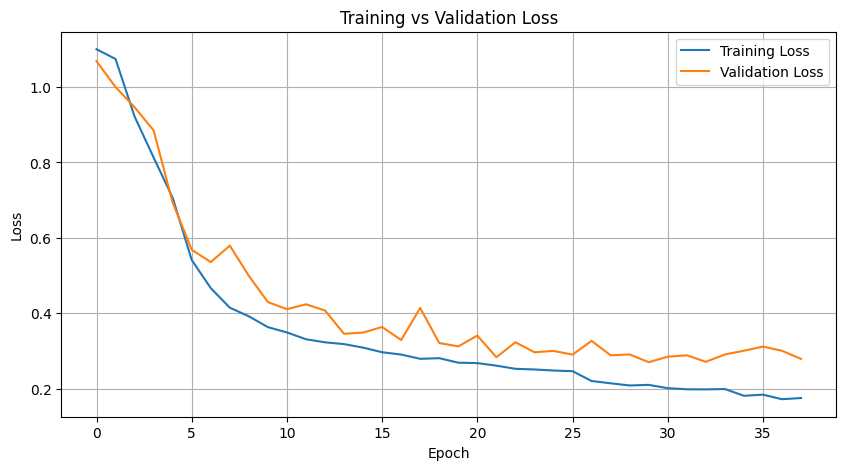

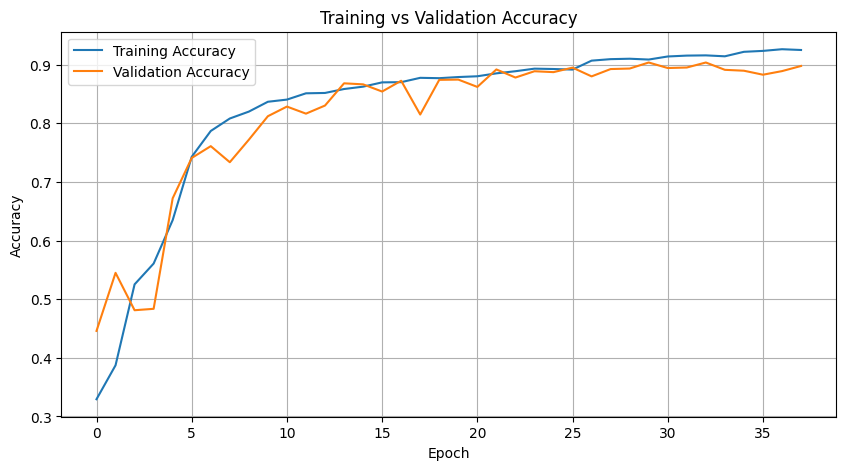

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
Accuracy: 0.9050854888206927
Precision: 0.8842133991206605
Recall: 0.9276088992974239
F1 Score: 0.9021093718610813

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.95      0.91      1000
           1       0.82      0.97      0.89      1000
           2       0.97      0.86      0.91      2562

    accuracy                           0.91      4562
   macro avg       0.88      0.93      0.90      4562
weighted avg       0.91      0.91      0.91      4562



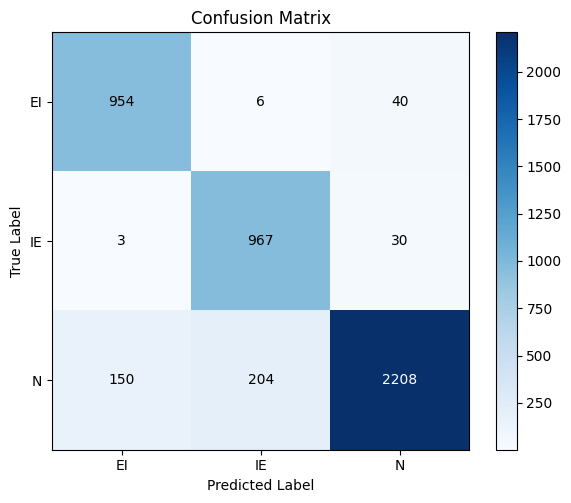

In [16]:
cm = confusion_matrix(y_true, y_pred)
class_names = ["EI", "IE", "N"]

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()
plt.show()

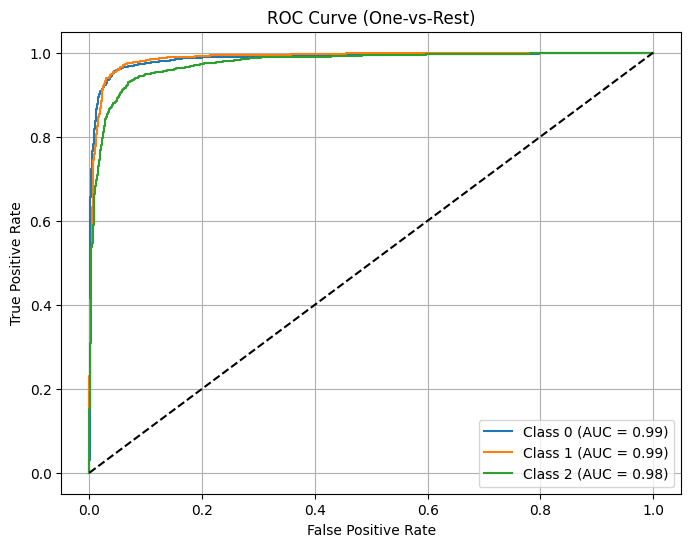

AUC scores per class: {0: np.float64(0.9871428972487366), 1: np.float64(0.9885642897248738), 2: np.float64(0.9753788056206087)}


In [17]:
n_classes = y_test.shape[1]

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()

print("AUC scores per class:", roc_auc)

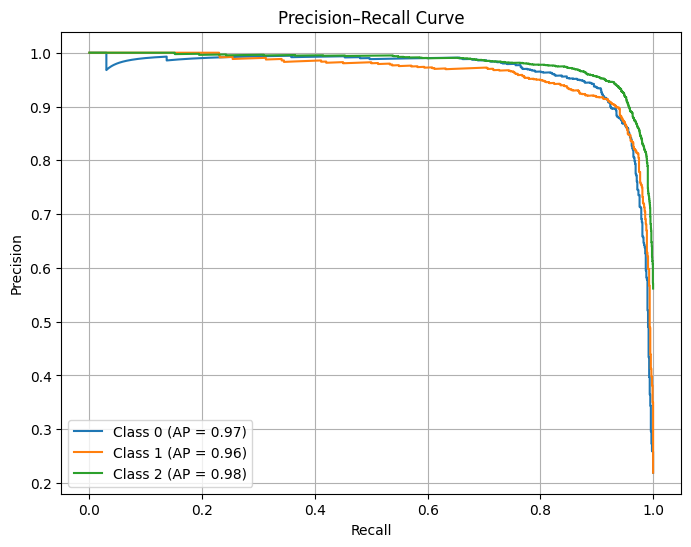

Average Precision per class: {0: np.float64(0.9653764620428101), 1: np.float64(0.9622135836484897), 2: np.float64(0.9805057578008686)}


In [18]:
precision_curve = {}
recall_curve = {}
avg_precision = {}

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    precision_curve[i], recall_curve[i], _ = precision_recall_curve(y_test[:, i], y_pred_prob[:, i])
    avg_precision[i] = average_precision_score(y_test[:, i], y_pred_prob[:, i])

    plt.plot(
        recall_curve[i],
        precision_curve[i],
        label=f"Class {i} (AP = {avg_precision[i]:.2f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

print("Average Precision per class:", avg_precision)

In [19]:
report = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

display(report_df)

,precision,recall,f1-score,support
0,0.861789,0.954000,0.905553,1000.000000
1,0.821580,0.967000,0.888379,1000.000000
2,0.969271,0.861827,0.912397,2562.000000
accuracy,0.905085,0.905085,0.905085,0.905085
macro avg,0.884213,0.927609,0.902109,4562.000000
weighted avg,0.913337,0.905085,0.905632,4562.000000


In [20]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

results = []

svm_model = SVC(kernel="rbf")
svm_model.fit(X_train_flat, y_train_labels)
svm_pred = svm_model.predict(X_test_flat)

results.append([
    "SVM",
    accuracy_score(y_test_labels, svm_pred),
    precision_score(y_test_labels, svm_pred, average="macro"),
    recall_score(y_test_labels, svm_pred, average="macro"),
    f1_score(y_test_labels, svm_pred, average="macro")
])

print("SVM Classification Report:\n")
print(classification_report(y_test_labels, svm_pred))

rf_model = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_model.fit(X_train_flat, y_train_labels)
rf_pred = rf_model.predict(X_test_flat)

results.append([
    "Random Forest",
    accuracy_score(y_test_labels, rf_pred),
    precision_score(y_test_labels, rf_pred, average="macro"),
    recall_score(y_test_labels, rf_pred, average="macro"),
    f1_score(y_test_labels, rf_pred, average="macro")
])

print("Random Forest Classification Report:\n")
print(classification_report(y_test_labels, rf_pred))

results.append([
    "CNN + BiLSTM",
    accuracy,
    precision,
    recall,
    f1
])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

display(results_df)

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.75      0.75      1000
           1       0.74      0.81      0.77      1000
           2       0.83      0.80      0.81      2562

    accuracy                           0.79      4562
   macro avg       0.77      0.79      0.78      4562
weighted avg       0.79      0.79      0.79      4562

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.36      0.51      1000
           1       0.85      0.58      0.69      1000
           2       0.70      0.94      0.80      2562

    accuracy                           0.74      4562
   macro avg       0.81      0.63      0.67      4562
weighted avg       0.77      0.74      0.71      4562



,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.791539,0.774874,0.785833,0.779886
1,Random Forest,0.736957,0.811810,0.628858,0.668283
2,CNN + BiLSTM,0.905085,0.884213,0.927609,0.902109


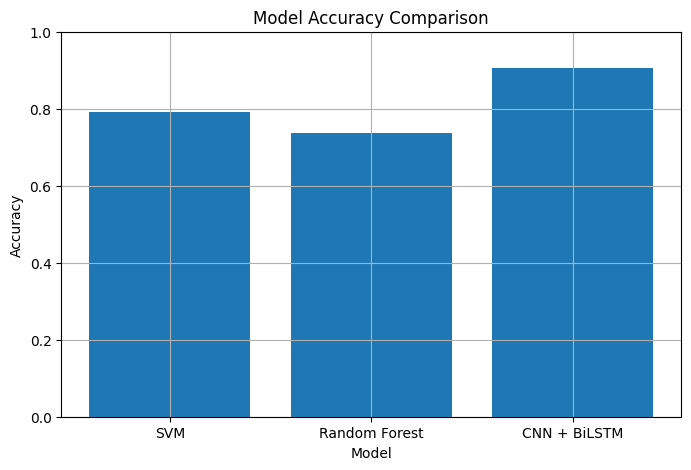

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [22]:
class_names = ["EI", "IE", "N"]

misclassified_idx = np.where(y_true != y_pred)[0]

print("Total misclassified samples:", len(misclassified_idx))

misclassified_df = pd.DataFrame({
    "Index": misclassified_idx,
    "True_Label": [class_names[y_true[i]] for i in misclassified_idx],
    "Predicted_Label": [class_names[y_pred[i]] for i in misclassified_idx]
})

display(misclassified_df.head(20))

confusion_pairs = misclassified_df.groupby(["True_Label", "Predicted_Label"]).size().reset_index(name="Count")
print("Misclassification summary:")
display(confusion_pairs)

n_errors = misclassified_df[misclassified_df["True_Label"] == "N"]
print("N class misclassified samples:", len(n_errors))
display(n_errors.head(20))

Total misclassified samples: 433


,Index,True_Label,Predicted_Label
0,6,N,EI
1,20,N,EI
2,31,N,IE
3,34,N,IE
4,48,N,EI
5,55,N,IE
6,59,IE,N
7,94,N,IE
8,97,N,EI
9,98,N,EI


Misclassification summary:


,True_Label,Predicted_Label,Count
0,EI,IE,6
1,EI,N,40
2,IE,EI,3
3,IE,N,30
4,N,EI,150
5,N,IE,204


N class misclassified samples: 354


,Index,True_Label,Predicted_Label
0,6,N,EI
1,20,N,EI
2,31,N,IE
3,34,N,IE
4,48,N,EI
5,55,N,IE
7,94,N,IE
8,97,N,EI
9,98,N,EI
10,111,N,IE


In [23]:
units_list = [32, 64, 128]
hp_results = []

for units in units_list:
    input_layer = Input(shape=(MAX_LEN, 4))

    x = Conv1D(filters=64, kernel_size=5, activation="relu", padding="same")(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    x = Conv1D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(units, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = GlobalMaxPooling1D()(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    output_layer = Dense(3, activation="softmax")(x)

    temp_model = Model(inputs=input_layer, outputs=output_layer)
    temp_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    temp_history = temp_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    best_val_acc = max(temp_history.history["val_accuracy"])
    hp_results.append([units, best_val_acc])

hp_results_df = pd.DataFrame(hp_results, columns=["BiLSTM Units", "Best Validation Accuracy"])
display(hp_results_df)

,BiLSTM Units,Best Validation Accuracy
0,32,0.794608
1,64,0.855984
2,128,0.865629


Filter shape: (5, 4, 64)


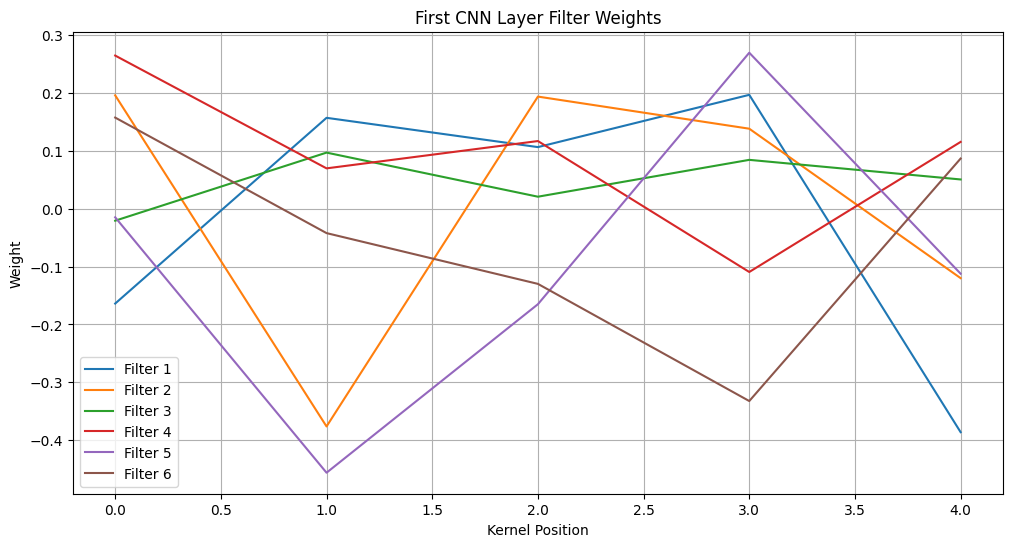

In [24]:
filters, biases = model.layers[1].get_weights()

print("Filter shape:", filters.shape)

plt.figure(figsize=(12, 6))
for i in range(min(6, filters.shape[2])):
    plt.plot(filters[:, 0, i], label=f"Filter {i+1}")

plt.title("First CNN Layer Filter Weights")
plt.xlabel("Kernel Position")
plt.ylabel("Weight")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
model.save("final_cnn_bilstm_splice_model.keras")
results_df.to_csv("model_comparison_results.csv", index=False)
report_df.to_csv("classification_report_table.csv")

with open("final_model_metrics.txt", "w") as f:
    f.write(f"Accuracy: {accuracy}\n")
    f.write(f"Precision: {precision}\n")
    f.write(f"Recall: {recall}\n")
    f.write(f"F1 Score: {f1}\n")
    f.write(f"AUC Scores: {roc_auc}\n")
    f.write(f"Average Precision Scores: {avg_precision}\n")

print("Model and results saved successfully.")

Model and results saved successfully.
